# bellhop3d - rtrs validation tests

Comparison of `rtrs` against Bellhop3d across ASA wedge scenarios I, II, and 
III.  

To run this notebook, first install rtrs with the python bindings. Then create
a folder in the root of the repo called 'bins' and copy the bellhop3d 
executable there. Then inside this folder, create another folder called 
`envs`, this is where the bellhop3d environment files will go. If these 
folders have already been created for the bellhop2d validation notebook, then
you can reuse those folders and just add the bellhop3d executable to the 
`bins` folder.

## ASA wedge background
This problem is used as a reference for validating 3D acoustic propagation [1]
[2]. The parameters of the problems are summarised in a table below. 

| Parameter | Value | Notes |
|---|---|---|
| **Geometry** | | |
| Water depth at source (X = 0) | 200 m | Decreases linearly to 0 at apex |
| Wedge apex range | 4 km | X = 4000 m |
| Slope angle | 2.86° (π/63 rad) | 1/20 slope |
| Source depth | 100 m | Point source (3D) |
| Frequency | 25 Hz | Low for ray tracing |
| Receiver depth (TL curves) | 30 m, 150 m | Along up/down-slope plane |
| **Water column** | | |
| Sound speed c_w | 1500 m/s | Isovelocity |
| Density ρ_w | 1000 kg/m³ (1 g/cc) | |
| Attenuation α_w | 0 dB/λ | Lossless |
| **Bottom** (Problems II/III) | | |
| Sound speed c_b | 1700 m/s | Liquid half-space |
| Density ρ_b | 1500 kg/m³ | |
| Attenuation α_b | 0.5 dB/λ | Problem III (lossy); 0 for II |

### ASA wedge scenario I
Perfectly reflecting boundaries, the only problem with a closed-form analytical
solution [2]. The analytical solution is compared to the Bellhop3D and RTRS
solutions.

The original ASA benchmark uses pressure-release (soft) boundaries at *both* the
sea surface and the seabed. RTRS models a vacuum (pressure-release / "soft")
surface but its perfectly-reflecting seabed is *rigid* ("hard", reflection
coefficient $+1$), so here we run the perfectly-reflecting wedge with a
**soft surface / rigid bottom** ("soft/hard") configuration for all three
solutions. Both boundaries are still perfectly reflecting.

Buckingham & Tolstoy's velocity-potential solution [2] holds for either boundary
combination; only the modal orders change. With a pressure-release surface at
angular depth $\theta = 0$ the modes are $\sin(\nu\theta)$, and the seabed
boundary at $\theta = \theta_0$ fixes the order $\nu$:

* soft/soft (original benchmark): $\sin(\nu\theta_0) = 0 \Rightarrow \nu_n = n\pi/\theta_0$
  (integer orders, $n = 1, 2, 3, \dots$).
* soft/hard (used here): $\cos(\nu\theta_0) = 0 \Rightarrow \nu_n = (n-\tfrac{1}{2})\pi/\theta_0$
  (half-integer orders).

The radial part $J_\nu H^{(1)}_\nu$ and the $i\pi/\theta_0$ prefactor are
identical in both cases. Buckingham & Tolstoy give the field for a 2-D line
source, but RTRS and Bellhop3D use 3-D point sources. Because the wedge is
invariant in the cross-slope (out-of-plane) direction $y$, the point-source
field is the Fourier synthesis of the line source over the cross-slope
wavenumber $k_y$:

$$
G_{3D} = \frac{1}{\pi}\int_0^\infty \Psi(\kappa)\,dk_y,
\qquad \kappa = \sqrt{k^2 - k_y^2}
$$

i.e. only $k \to \kappa$ changes inside the Bessel/Hankel arguments (the angular
eigenfunctions are $k$-independent and pass through the integral). $G_{3D}$ is
the $-\delta^3$ Green's function, so $\mathrm{TL} = -20\log_{10}|4\pi\,G_{3D}|$
gives absolute TL and the near field rolls off spherically ($20\log_{10} R$).
This is what `wedge_analytical_tl(..., point_source=True)` computes; the
`half_integer` flag selects the boundary case.

### ASA wedge scenario II
This problem has penetrating boundaries, but the bottom is lossless. There is 
no analytical solution for this problem and in the absence of a reference
solution, the Bellhop3D and RTRS solutions are compared to each other. 
Comparisons of Bellhop3D to reference solutions can be found in the
litureature.

### ASA wedge scenario III
This problem has penetrating boundaries, but the bottom is lossy, 0.5 dB per 
wavelength.
There is no analytical solution for this problem and in the absence of a 
reference solution, the Bellhop3D and RTRS solutions are compared to each 
other. Comparisons of Bellhop3D to reference solutions can be found in the
litureature.

## References
[1]   Jensen, Finn B., and Carlo M. Ferla. "Numerical solutions of 
      range‐dependent benchmark problems in ocean acoustics." The Journal of 
      the Acoustical Society of America 87.4 (1990): 1499-1510.
[2]   Buckingham, Michael J., and Alexandra Tolstoy. "An analytical solution 
      for benchmark problem 1: The ‘‘ideal’’wedge." The Journal of the 
      Acoustical Society of America 87.4 (1990): 1511-1513.

## Bellhop3D helper functions

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
import subprocess

import rtrs
import python_utils

# helper functions to deal with bellhop
def create_bellhop3d_env(
    env_name,
    env_dir,
    freq,
    ssp_header,   # tuple: (nssp, zmin, zmax)  - for example, (51, 0.0, 20000.0)
    ssp,          # list of tuples (range, speed); e.g., [(0.0, 1548.52), (200.0, 1530.29), ...]
    bottom_bc="A~",
    bottom_props=[20000.0, 1600.00, 0.0, 1.8, 0.8],
    source_x=[0.0],     # list of source x-coordinates in km
    source_y=[0.0],     # list of source y-coordinates in km
    source_depth=[1000.0],  # list of source depths in m
    receiver_depths=[1000.0, 5000.0],  # list of receiver depths in m
    nr=1001,            # number of receiver range points
    range_limits=(0.0, 100.0),  # tuple: (range_min, range_max) in km
    bearing=(6, [0.0, 360.0]),   # tuple: (ntheta, [min_angle, max_angle]) in degrees
    run_opt="RG   3",
    nalpha=10,
    alpha_range=(-10, 10),  # (min_alpha, max_alpha) in degrees
    nbeta=5,
    beta_range=(0, 300),     # (min_beta, max_beta) in degrees
    step_info=(0.0, 99.1, 99.1, 20500.0),
    nmedia=1,
    ssopt="CVW"
):
    """
    Creates a 3D environmental file for Bellhop3D simulations.

    This function generates a '.env' file for Bellhop3D based on the specified
    parameters, including sound speed profile (SSP) information, bottom properties,
    source and receiver locations, and beam fan parameters.

    Parameters
    ----------
    env_name : str
        Environment name, used as the filename prefix.
    env_dir : str
        Directory in which to write the environment file.
    freq : float
        Acoustic frequency in Hz.
    ssp_header : tuple
        A tuple (nssp, zmin, zmax) specifying the SSP header where:
            - nssp is the number of points for the SSP section (e.g., 51),
            - zmin is the starting depth (m), and
            - zmax is the maximum depth of the medium (m).
    ssp : list of tuple
        The sound speed profile given as a list of (range, speed) pairs.
    bottom_bc : str, optional
        Bottom boundary condition (default is "A~").
    bottom_props : list of float, optional
        Bottom halfspace properties as a list of values (default is [20000.0, 1600.00, 0.0, 1.8, 0.8]).
    source_x : list of float, optional
        List of source x-coordinates (km) (default is [0.0]).
    source_y : list of float, optional
        List of source y-coordinates (km) (default is [0.0]).
    source_depth : list of float, optional
        List of source depths (m) (default is [1000.0]).
    receiver_depths : list of float, optional
        List of receiver depths (m) (default is [1000.0, 5000.0]).
    nr : int, optional
        Number of receiver range points (default is 1001).
    range_limits : tuple, optional
        A tuple (range_min, range_max) in km (default is (0.0, 100.0)).
    bearing : tuple, optional
        A tuple (ntheta, [min_angle, max_angle]) where ntheta is the number
        of receiver bearings and [min_angle, max_angle] are the bearing limits in degrees
        (default is (6, [0.0, 360.0])).
    run_opt : str, optional
        Run option string (e.g., 'RG   3') (default is "RG   3").
    nalpha : int, optional
        Number of elevation (declination) beams (default is 10).
    alpha_range : tuple, optional
        Tuple (min_alpha, max_alpha) in degrees for the elevation fan (default is (-10, 10)).
    nbeta : int, optional
        Number of azimuth beams (default is 5).
    beta_range : tuple, optional
        Tuple (min_beta, max_beta) in degrees for the azimuth fan (default is (0, 300)).
    step_info : tuple, optional
        Tuple (STEP, Box%x, Box%y, Box%z) defining the grid parameters (default is (0.0, 99.1, 99.1, 20500.0)).
    nmedia : int, optional
        Number of media (default is 1).
    ssopt : str, optional
        SSP option string (default is "CVW").

    Notes
    -----
    The file is written in sections corresponding to the Bellhop3D input format:
      1. Title, frequency, and sound speed profile.
      2. Bottom boundary and halfspace properties.
      3. Source coordinate specification (x, y, and depth).
      4. Receiver specification (receiver depths, range grid, and bearing angles).
      5. Run type and beam fan parameters.

    See :contentReference[oaicite:4]{index=4}&#8203;:contentReference[oaicite:5]{index=5} for Bellhop3D specifics and :contentReference[oaicite:6]{index=6}&#8203;:contentReference[oaicite:7]{index=7} for details on the environmental file format.
    """
    # Construct the filename.
    filename_env = os.path.join(env_dir, f"{env_name}.env")
    
    # Remove the file if it already exists.
    if os.path.exists(filename_env):
        os.remove(filename_env)
    
    with open(filename_env, "w") as file:
        # --- Section 1: Title, Frequency, Media, and SSP ---
        file.write(f"'{env_name}'\n")
        file.write(f"{freq}\n")
        file.write(f"{nmedia}\n")
        file.write(f"'{ssopt}'\n")
        
        # Write the SSP header: (nssp, zmin, zmax)
        file.write(f"{ssp_header[0]}  {ssp_header[1]}  {ssp_header[2]}\n")
        
        # Write each SSP data point.
        for point in ssp:
            file.write(f"{point[0]}  {point[1]}  /\n")
        
        # --- Section 2: Bottom Boundary and Halfspace Properties ---
        file.write(f"'{bottom_bc}' 0.0\n")
        # Rigid ('R') and vacuum ('V') bottoms are perfectly reflecting and have
        # no acousto-elastic halfspace, so Bellhop does not read a properties line
        # for them. Writing one would shift the rest of the file and break parsing.
        if bottom_bc[0] not in ("R", "V"):
            file.write(" ".join(str(x) for x in bottom_props) + " /\n")
        
        # --- Section 3: Source Coordinates ---
        # Source x-coordinates.
        file.write(f"{len(source_x)}\n")
        for x in source_x:
            file.write(f"{x} ")
        file.write(f"/\n")  # Duplicate for y-coordinates
        # Source y-coordinates.
        file.write(f"{len(source_y)}\n")
        for y in source_y:
            file.write(f"{y} ")
        file.write(f"/\n") 
        # Source depths.
        file.write(f"{len(source_depth)}\n")
        for sd in source_depth:
            file.write(f"{sd} ")
        file.write(f"/\n") 
        
        # --- Section 4: Receiver Depths, Ranges, and Bearings ---
        # Receiver depths.
        file.write(f"{len(receiver_depths)}\n")
        file.write(" ".join(str(rd) for rd in receiver_depths) + " /\n")
        # Number of receiver range points and range limits.
        if nr == 1:
            file.write(f"{nr}\n")
            file.write(f"{range_limits[1]} /\n")
        else:
            file.write(f"{nr}\n")
            file.write(f"{range_limits[0]}  {range_limits[1]} /\n")
        # Receiver bearings.
        file.write(f"{bearing[0]}\n")
        file.write(" ".join(str(angle) for angle in bearing[1]) + " /\n")
        
        # --- Section 5: Run Option and Beam Fan Parameters ---
        file.write(f"'{run_opt}'\n")
        file.write(f"{nalpha}\n")
        file.write(f"{alpha_range[0]} {alpha_range[1]} /\n")
        file.write(f"{nbeta}\n")
        file.write(f"{beta_range[0]} {beta_range[1]} /\n")
        file.write(" ".join(str(val) for val in step_info))


def rr_ray3d(filename=None):
    """
    Reads a 3D ray file (x,y,z coordinates) and returns lists of rays.
    
    The file is assumed to have a header with the following lines:
      1. A title string (e.g. 'Korean Sea 3D (3D run)')
      2. A frequency value (float)
      3. Three integers (Nsx, Nsy, Nsz) separated by whitespace
      4. Two integers (Nalpha, Nbeta) for the beam angles
      5. A depth value (DEPTHT)
      6. A depth value (DEPTHB)
      7. A type string (e.g. "'xyz'")
      
    After the header, the file contains ray data in a nested structure:
      For each spatial index (from the first two Ns),
      then for each beam-angle index (Nbeta, then Nalpha),
      the following values are read:
          - alpha0: a float (launch angle)
          - A line with three integers: nsteps, NumTopBnc, NumBotBnc.
          - nsteps lines, each with three float values representing x, y, z.
    
    The function collects the ray information in three lists:
      xs, ys, zs -- each is a list of NumPy arrays containing the ray coordinates.
    
    Parameters:
      filename : str
         Path to the ray file.
    
    Returns:
      xs, ys, zs : tuple of lists of numpy.ndarray
         Each list element corresponds to a ray's x-, y-, or z-coordinates.
    """
    
    xs = []
    ys = []
    zs = []
    
    with open(filename, 'r') as fid:
        # Read header information:
        title = fid.readline().strip()
        freq = float(fid.readline().strip())
        
        # Nsxyz line: expects three numbers (e.g. "2 2 1")
        ns_line = fid.readline().split()
        # In many ray files these are the spatial indices.
        try:
            Nsx, Nsy, Nsz = int(ns_line[0]), int(ns_line[1]), int(ns_line[2])
        except IndexError:
            raise ValueError("Header does not contain three Ns values (Nsx, Nsy, Nsz).")
            
        # Read beam angle counts (e.g., "30 4")
        beam_line = fid.readline().split()
        try:
            Nalpha, Nbeta = int(beam_line[0]), int(beam_line[1])
        except IndexError:
            raise ValueError("Header does not contain two beam angle values (Nalpha, Nbeta).")
            
        DEPTHT = float(fid.readline().strip())
        DEPTHB = float(fid.readline().strip())
        
        # Read the type string.
        ray_type_line = fid.readline().strip()
        # Remove quotes if they are present.
        if ray_type_line.startswith("'") and ray_type_line.endswith("'"):
            ray_type = ray_type_line[1:-1]
        else:
            ray_type = ray_type_line
        
        # Depending on file structure, there might be extra header lines.
        # (In the MATLAB code, sometimes two fgetl calls are made for the type.)
        # If needed, uncomment the following line:
        # extra_header = fid.readline().strip()
        
        # For 3D, we assume ray_type starts with 'xy' (or 'xyz') and expect 3 numbers per ray step.
        # Loop over spatial indices. (For 3D files, often Nsz==1 and only Nsx and Nsy are used.)
        for ix in range(Nsx):
            for iy in range(Nsy):
                for ibeta in range(Nbeta):
                    for ialpha in range(Nalpha):
                        # Read the initial ray parameter (alpha0)
                        line = fid.readline()
                        if not line:
                            # Reached end-of-file unexpectedly.
                            break
                        try:
                            alpha0 = float(line.strip())
                        except ValueError:
                            # In case the line is empty or not a valid float.
                            break
                        
                        # Read the line with nsteps, NumTopBnc, NumBotBnc.
                        param_line = fid.readline()
                        if not param_line:
                            break
                        parts = param_line.split()
                        if len(parts) < 3:
                            break
                        nsteps = int(parts[0])
                        # The following values are available if needed:
                        NumTopBnc = int(parts[1])
                        NumBotBnc = int(parts[2])
                        
                        # Preallocate arrays for this ray's x, y, z positions.
                        ray_x = np.zeros(nsteps)
                        ray_y = np.zeros(nsteps)
                        ray_z = np.zeros(nsteps)
                        
                        # Read the ray points.
                        for s in range(nsteps):
                            point_line = fid.readline()
                            if not point_line:
                                break
                            point_vals = point_line.split()
                            # Expect three float values per line: x, y, z.
                            if len(point_vals) < 3:
                                continue
                            ray_x[s] = float(point_vals[0])
                            ray_y[s] = float(point_vals[1])
                            ray_z[s] = float(point_vals[2])
                            
                        xs.append(ray_x)
                        ys.append(ray_y)
                        zs.append(ray_z)
    
    return xs, ys, zs

def readshd(filename=None, xs=np.nan, ys=np.nan):
    """
    read shd file
    :param filename:
    :param xs:
    :param ys:
    :return:
    """

    fid = open(filename, 'rb')
    # recl = int(np.fromfile(fid, np.int32, 1))
    recl = int(np.fromfile(fid, np.int32, 1)[0])
    title = fid.read(80)
    fid.seek(4 * recl)
    PlotType = fid.read(10)
    fid.seek(2 * 4 * recl)  # reposition to end of second record

    Nfreq = int(np.fromfile(fid, np.int32, 1)[0])
    Ntheta = int(np.fromfile(fid, np.int32, 1)[0])
    Nsx = int(np.fromfile(fid, np.int32, 1)[0])
    Nsy = int(np.fromfile(fid, np.int32, 1)[0])
    Nsd = int(np.fromfile(fid, np.int32, 1)[0])
    Nrd = int(np.fromfile(fid, np.int32, 1)[0])
    Nrr = int(np.fromfile(fid, np.int32, 1)[0])
    atten = float(np.fromfile(fid, np.float32, 1)[0])

    # reposition to end of record 3
    fid.seek(3 * 4 * recl)
    freqVec = np.fromfile(fid, np.float32, Nfreq)

    # reposition to end of record 4
    fid.seek(4 * 4 * recl)
    thetas = np.fromfile(fid, np.float32, Ntheta)

    if PlotType[0: 1] != 'TL':
        # reposition to end of record 4
        fid.seek(5 * 4 * recl)
        Xs = np.fromfile(fid, np.float32, Nsx)

        # reposition to end of record 5
        fid.seek(6 * 4 * recl)
        Ys = np.fromfile(fid, np.float32, Nsy)
    else:  # compressed format for TL from FIELD3D
        # reposition to end of record 4
        fid.seek(5 * 4 * recl)
        Pos_S_x = np.fromfile(fid, np.float32, 2)
        Xs = np.linspace(Pos_S_x[0], Pos_S_x[1], Nsx)

        # reposition to end of record 5
        fid.seek(6 * 4 * recl)
        Pos_S_y = np.fromfile(fid, np.float32, 2)
        Ys = np.linspace(Pos_S_y[0], Pos_S_y[1], Nsy)

    # reposition to end of record 6
    fid.seek(7 * 4 * recl)
    zs = np.fromfile(fid, np.float32, Nsd)

    # reposition to end of record 7
    fid.seek(8 * 4 * recl)
    zarray = np.fromfile(fid, np.float32, Nrd)

    # reposition to end of record 8
    fid.seek(9 * 4 * recl)
    rarray = np.fromfile(fid, np.float32, Nrr)
    if PlotType == 'rectilin  ':
        pressure = np.zeros((Ntheta, Nsd, Nrd, Nrr)) + 1j * np.zeros((Ntheta, Nsd, Nrd, Nrr))
        Nrcvrs_per_range = Nrd
    elif PlotType == 'irregular ':
        pressure = np.zeros((Ntheta, Nsd, 1, Nrr)) + 1j * np.zeros((Ntheta, Nsd, Nrd, Nrr))
        Nrcvrs_per_range = 1
    else:
        pressure = np.zeros((Ntheta, Nsd, Nrd, Nrr))
        Nrcvrs_per_range = Nrd

    pressure = np.zeros((Ntheta, Nsd, Nrcvrs_per_range, Nrr)) + 1j * np.zeros((Ntheta, Nsd, Nrcvrs_per_range, Nrr))

    if np.isnan(xs):
        for itheta in range(Ntheta):
            for isd in range(Nsd):
                for ird in range(Nrcvrs_per_range):
                    recnum = 10 + itheta * Nsd * Nrcvrs_per_range + isd * Nrcvrs_per_range + ird

                    # Move to end of previous record
                    status = fid.seek(recnum * 4 * recl)
                    if status == -1:
                        print('Seek to specified record failed in readshd...')

                    # Read complex data
                    temp = np.fromfile(fid, np.float32, 2 * Nrr)
                    for k in range(Nrr):
                        pressure[itheta, isd, ird, k] = temp[2 * k] + 1j * temp[2 * k + 1]

    else:
        xdiff = abs(Xs - xs * 1000.0)
        idxX = xdiff.argmin(0)
        ydiff = abs(Ys - ys * 1000.0)
        idxY = ydiff.argmin(0)

        for itheta in range(Ntheta):
            for isd in range(Nsd):
                for ird in range(Nrcvrs_per_range):

                    recnum = (10 + idxX * Nsy * Ntheta * Nsd * Nrcvrs_per_range + idxY * Ntheta * Nsd * Nrcvrs_per_range
                              + itheta * Nsd * Nrcvrs_per_range + isd * Nrcvrs_per_range + ird)

                    # Move to end of previous record
                    status = fid.seek(recnum * 4 * recl)
                    if status == -1:
                        print('Seek to specified record failed in read_shd_bin')

                    temp = np.fromfile(fid, np.float32, 2 * Nrr)  # Read complex data
                    for k in range(Nrr):
                        pressure[itheta, isd, ird, k] = temp[2 * k] + 1j * temp[2 * k + 1]

        fid.close()

    geometry = {"xyzs": (Xs,Ys,zs), "f": freqVec, "thetas": thetas, "rarray": rarray, "zarray": zarray}

    return pressure, geometry


def Munk(Z, min_c=1500.0, epsilon=0.00737, min_z1=1300.0, min_z2=1300.0):
    """
    Make munk ssp
    :param Z: (numpy.ndarray)
    :param min_c: (float)
    :param epsilon: (float)
    :param min_z1: (float)
    :param min_z2: (float)
    :return: ssp, c (list, numpy.ndarray)
    """

    # Calculate Munk profile
    zbar = (2 * (Z - min_z1)) / min_z2
    c = min_c * (1.0 + epsilon * (zbar - 1 + np.exp(-zbar)))

    # Formate data for output
    ssp = [(depth, speed) for depth, speed in zip(Z, c)]

    return ssp, c

BELLCXX3D = "../bins/bellhopcxx"

def run_bellhop3d(bin_path, env_dir, env_name, expected_ext):
    expected_file = os.path.join(env_dir, f"{env_name}.{expected_ext}")
    if os.path.exists(expected_file):
        os.remove(expected_file)
    proc = subprocess.run(
        [bin_path, os.path.join(env_dir, env_name), "--3D"],
        capture_output=True,
        text=True,
    )
    if proc.returncode != 0:
        raise RuntimeError(
            f"Bellhop3D failed for {env_name}.\nstdout:\n{proc.stdout}\nstderr:\n{proc.stderr}"
        )
    if not os.path.exists(expected_file):
        raise FileNotFoundError(f"Bellhop3D did not produce expected file: {expected_file}")

def create_3d_bty(env_name, env_dir, x, y, z_grid):
    z_grid = np.asarray(z_grid)
    x = np.asarray(x)
    y = np.asarray(y)
    ny, nx = z_grid.shape

    with open(os.path.join(env_dir, f"{env_name}.bty"), "w") as file:
        file.write("'R'\n")
        file.write(f"{nx}\n")
        file.write(f"{x[0]:.6f} {x[-1]:.6f} /\n")
        file.write(f"{ny}\n")
        file.write(f"{y[0]:.6f} {y[-1]:.6f} /\n")
        for row in z_grid:
            file.write(" ".join(f"{val:.6f}" for val in row) + "\n")

def readshd(filename=None, xs=np.nan, ys=np.nan):
    fid = open(filename, 'rb')
    recl = int(np.fromfile(fid, np.int32, 1)[0])
    _title = fid.read(80)
    fid.seek(4 * recl)
    PlotType = fid.read(10).decode(errors="ignore")
    fid.seek(2 * 4 * recl)

    Nfreq = int(np.fromfile(fid, np.int32, 1)[0])
    Ntheta = int(np.fromfile(fid, np.int32, 1)[0])
    Nsx = int(np.fromfile(fid, np.int32, 1)[0])
    Nsy = int(np.fromfile(fid, np.int32, 1)[0])
    Nsd = int(np.fromfile(fid, np.int32, 1)[0])
    Nrd = int(np.fromfile(fid, np.int32, 1)[0])
    Nrr = int(np.fromfile(fid, np.int32, 1)[0])
    _atten = float(np.fromfile(fid, np.float32, 1)[0])

    fid.seek(3 * 4 * recl)
    freqVec = np.fromfile(fid, np.float32, Nfreq)

    fid.seek(4 * 4 * recl)
    thetas = np.fromfile(fid, np.float32, Ntheta)

    if PlotType[0:2] != 'TL':
        fid.seek(5 * 4 * recl)
        Xs = np.fromfile(fid, np.float32, Nsx)
        fid.seek(6 * 4 * recl)
        Ys = np.fromfile(fid, np.float32, Nsy)
    else:
        fid.seek(5 * 4 * recl)
        Pos_S_x = np.fromfile(fid, np.float32, 2)
        Xs = np.linspace(Pos_S_x[0], Pos_S_x[1], Nsx)
        fid.seek(6 * 4 * recl)
        Pos_S_y = np.fromfile(fid, np.float32, 2)
        Ys = np.linspace(Pos_S_y[0], Pos_S_y[1], Nsy)

    fid.seek(7 * 4 * recl)
    zs = np.fromfile(fid, np.float32, Nsd)
    fid.seek(8 * 4 * recl)
    zarray = np.fromfile(fid, np.float32, Nrd)
    fid.seek(9 * 4 * recl)
    rarray = np.fromfile(fid, np.float32, Nrr)

    if PlotType == 'rectilin  ':
        Nrcvrs_per_range = Nrd
    elif PlotType == 'irregular ':
        Nrcvrs_per_range = 1
    else:
        Nrcvrs_per_range = Nrd

    pressure = np.zeros((Ntheta, Nsd, Nrcvrs_per_range, Nrr)) + 1j * np.zeros((Ntheta, Nsd, Nrcvrs_per_range, Nrr))

    if np.isnan(xs):
        for itheta in range(Ntheta):
            for isd in range(Nsd):
                for ird in range(Nrcvrs_per_range):
                    recnum = 10 + itheta * Nsd * Nrcvrs_per_range + isd * Nrcvrs_per_range + ird
                    fid.seek(recnum * 4 * recl)
                    temp = np.fromfile(fid, np.float32, 2 * Nrr)
                    for k in range(Nrr):
                        pressure[itheta, isd, ird, k] = temp[2 * k] + 1j * temp[2 * k + 1]
    else:
        xdiff = abs(Xs - xs * 1000.0)
        idxX = xdiff.argmin(0)
        ydiff = abs(Ys - ys * 1000.0)
        idxY = ydiff.argmin(0)

        for itheta in range(Ntheta):
            for isd in range(Nsd):
                for ird in range(Nrcvrs_per_range):
                    recnum = (10 + idxX * Nsy * Ntheta * Nsd * Nrcvrs_per_range + idxY * Ntheta * Nsd * Nrcvrs_per_range
                              + itheta * Nsd * Nrcvrs_per_range + isd * Nrcvrs_per_range + ird)
                    fid.seek(recnum * 4 * recl)
                    temp = np.fromfile(fid, np.float32, 2 * Nrr)
                    for k in range(Nrr):
                        pressure[itheta, isd, ird, k] = temp[2 * k] + 1j * temp[2 * k + 1]

    fid.close()
    geometry = {"xyzs": (Xs, Ys, zs), "f": freqVec, "thetas": thetas, "rarray": rarray, "zarray": zarray}
    return pressure, geometry

def safe_tl(values):
    return -20 * np.log10(np.maximum(np.abs(values), 1e-30))

## Analytical Wedge I Solution

In [25]:
from scipy.special import jv, hankel1

# --- Wedge geometry, common to all three ASA benchmark problems -------------
FREQ_HZ = 25.0            # source frequency (Hz)
C_W = 1500.0             # isovelocity water sound speed (m/s)
SLOPE = 1.0 / 20.0       # bottom slope (tan of the wedge angle)
APEX_M = 4000.0          # up-slope distance from the source to the wedge apex (m)
SRC_DEPTH = 100.0        # source depth (m), mid-water at the source position
DEPTH_AT_SRC = 200.0     # water depth at the source position (m)
THETA0 = np.arctan(SLOPE)                 # wedge angle (rad)
K_W = 2.0 * np.pi * FREQ_HZ / C_W         # water wavenumber (rad/m)


def wedge_depth_m(range_from_source_m):
    """Water depth (m) a distance ``range_from_source_m`` up-slope of the source."""
    d = DEPTH_AT_SRC - SLOPE * np.asarray(range_from_source_m, dtype=float)
    return np.maximum(d, 1.0)             # 1 m floor to avoid a zero-thickness apex


def _wedge_orders(n_modes, half_integer):
    n = np.arange(1, n_modes + 1)
    return ((n - 0.5) if half_integer else n) * np.pi / THETA0


def wedge_analytical_tl(range_from_source_m, rcvr_depth_m, n_modes=60,
                        half_integer=True, point_source=True,
                        atten=1e-3, n_ky=2500, ky_max_factor=8.0):
    r"""Analytical transmission loss for the ideal wedge (Buckingham & Tolstoy [2]).

    The 2-D line-source velocity potential is a sum of uncoupled normal modes

    $$
    \Psi(k) = \frac{i\pi}{\theta_0}\sum_n \sin(\nu\theta)\,\sin(\nu\theta_s)\,
              J_\nu(k r_<)\,H^{(1)}_\nu(k r_>)
    $$

    with $(r, \theta)$ / $(r_s, \theta_s)$ the polar coordinates of the receiver /
    source about the apex. The pressure-release surface fixes the mode shape
    $\sin(\nu\theta)$; the seabed boundary fixes the order $\nu$:

    * ``half_integer=False`` $\Rightarrow \nu_n = n\pi/\theta_0$ (soft/soft, integer)
    * ``half_integer=True``  $\Rightarrow \nu_n = (n-\tfrac{1}{2})\pi/\theta_0$ (soft/hard, half-integer)

    ``point_source=False`` returns the 2-D line-source TL normalised to the line
    source at 1 m, $\Phi(1) = \tfrac{i}{4} H^{(1)}_0(k)$.

    ``point_source=True`` (default) returns the physically correct 3-D point-source
    TL for the $y = 0$ (up/down-slope) plane, built by Fourier-synthesising the line
    source over the cross-slope wavenumber $k_y$ (the wedge is invariant in $y$):

    $$
    G_{3D} = \frac{1}{\pi}\int_0^\infty \Psi(\kappa)\,dk_y,
    \qquad \kappa = \sqrt{k^2 - k_y^2}
    $$

    Only $k \to \kappa$ changes inside the Bessel/Hankel arguments; the angular
    eigenfunctions are $k$-independent. $G_{3D}$ is the $-\delta^3$ Green's function
    ($\to e^{ikR}/4\pi R$ as $R \to 0$), so $\mathrm{TL} = -20\log_{10}|4\pi\,G_{3D}|$
    and the near field rolls off spherically ($20\log_{10} R$). A tiny artificial
    attenuation (``atten``, in imaginary fraction of $k$) lifts the $k_y = k$ branch
    point off the real axis; convention is $e^{-i\omega t}$ (outgoing $H^{(1)}$,
    $\operatorname{Im}\kappa \ge 0$).

    The point-source path costs $O(n_\mathrm{range}\,n_{k_y}\,n_\mathrm{modes})$; pass
    a modest number of ``range_from_source_m`` points. It assumes the receiver is
    up-slope of the source ($r \le r_s$), which holds for the ASA wedge output geometry.
    """
    s = np.atleast_1d(np.asarray(range_from_source_m, dtype=float))
    r_src = np.hypot(APEX_M, SRC_DEPTH)          # source range from apex
    theta_src = np.arctan2(SRC_DEPTH, APEX_M)    # source angular depth
    nu = _wedge_orders(n_modes, half_integer)

    if not point_source:
        x_rcvr = APEX_M - s
        r = np.hypot(x_rcvr, rcvr_depth_m)
        theta = np.arctan2(rcvr_depth_m, x_rcvr)
        R = r[:, None]
        TH = theta[:, None]
        NU = nu[None, :]
        r_lt = np.minimum(R, r_src)
        r_gt = np.maximum(R, r_src)
        term = (jv(NU, K_W * r_lt) * hankel1(NU, K_W * r_gt)
                * np.sin(NU * TH) * np.sin(NU * theta_src))
        # Deeply evanescent modes (nu >> k r) overflow H_nu^(1); drop them.
        term = np.where(np.isfinite(term), term, 0.0)
        psi = (1j * np.pi / THETA0) * term.sum(axis=1)
        phi1 = (1j / 4.0) * hankel1(0, K_W)      # 2-D line source at 1 m
        return -20.0 * np.log10(np.maximum(np.abs(psi) / np.abs(phi1), 1e-30))

    # 3-D point source: k_y Fourier synthesis on the y = 0 plane.
    k = K_W * (1.0 + 1j * atten)                 # tiny attenuation lifts branch point
    ky = np.linspace(0.0, ky_max_factor * abs(k), n_ky)
    d_ky = ky[1] - ky[0]
    kappa = np.sqrt(k * k - ky * ky)
    kappa = np.where(kappa.imag < 0.0, -kappa, kappa)       # Im(kappa) >= 0
    # H_nu^(1)(kappa r_s) is receiver-independent (source is the far endpoint, r_> = r_s)
    hs = hankel1(nu[None, :], kappa[:, None] * r_src) * np.sin(nu * theta_src)[None, :]

    tl = np.empty(s.shape)
    for i, si in enumerate(s):
        x_rcvr = APEX_M - si
        r = np.hypot(x_rcvr, rcvr_depth_m)
        theta = np.arctan2(rcvr_depth_m, x_rcvr)
        jr = jv(nu[None, :], kappa[:, None] * r)
        integrand = (1j * np.pi / THETA0) * (jr * hs * np.sin(nu * theta)[None, :])
        integrand = np.where(np.isfinite(integrand), integrand, 0.0).sum(axis=1)
        # trapezoidal rule on the uniform k_y grid (even integrand -> factor 1/pi)
        g3d = (d_ky / np.pi) * (integrand.sum()
                                - 0.5 * (integrand[0] + integrand[-1]))
        tl[i] = -20.0 * np.log10(abs(4.0 * np.pi * g3d) + 1e-30)
    return tl


# --- Run helpers ------------------------------------------------------------
# Resolve the bins/ directory relative to this file (or the CWD when run as
# interactive '# %%' cells) so the example works from the repo root, from
# examples/, or interactively - not only when the CWD is examples/.
try:
    _base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _base_dir = os.getcwd()
_bins_dir = os.path.abspath(os.path.join(_base_dir, "..", "bins"))
if not os.path.isdir(_bins_dir):
    _bins_dir = os.path.abspath(os.path.join(_base_dir, "bins"))
env_dir = os.path.join(_bins_dir, "envs")
os.makedirs(env_dir, exist_ok=True)
BELLCXX3D = os.path.join(_bins_dir, "bellhopcxx")

# Receiver grid shared by every problem: a depth stack (for the 2-D TL fields)
# that also lands exactly on the benchmark receiver depths of 30 m and 150 m.
NR = 1000                                        # receiver ranges (source -> apex)
RCVR_DEPTHS = np.linspace(0.0, 200.0, 81)        # 2.5 m spacing: hits 30 m and 150 m
RANGE_MAX_KM = APEX_M / 1000.0
N_ELEV = 1500                                    # launch (declination) beams
N_AZIM = 3                                       # narrow azimuth fan (approx. slice)
AZIM_DEG = 0.5
ELEV_DEG = 80.0
STEP_M = 5.0


def rd_index(depth_m):
    return int(np.argmin(np.abs(RCVR_DEPTHS - depth_m)))


def run_wedge_bellhop(env_name, bottom_bc, bottom_props):
    """Run a wedge problem in Bellhop3D; return (TL[depth, range], ranges_m, depths_m)."""
    create_bellhop3d_env(
        env_name=env_name,
        env_dir=env_dir,
        freq=FREQ_HZ,
        ssp_header=(2, 0.0, DEPTH_AT_SRC),
        ssp=[(0.0, C_W), (DEPTH_AT_SRC, C_W)],
        bottom_bc=bottom_bc,
        bottom_props=bottom_props,
        source_x=[0.0],
        source_y=[0.0],
        source_depth=[SRC_DEPTH],
        receiver_depths=RCVR_DEPTHS.tolist(),
        nr=NR,
        range_limits=(0.0, RANGE_MAX_KM),
        bearing=(1, [0.0]),                      # single bearing along +x (up-slope)
        run_opt="Cb   3",                        # coherent Gaussian ray-centred beams, 3D
        nalpha=N_ELEV,
        alpha_range=(-ELEV_DEG, ELEV_DEG),
        nbeta=N_AZIM,
        beta_range=(-AZIM_DEG, AZIM_DEG),
        step_info=(STEP_M, RANGE_MAX_KM, RANGE_MAX_KM, DEPTH_AT_SRC + 50.0),
        nmedia=1,
        ssopt="CVW",
    )
    # Sloping bottom, read from the .bty file (bearing 0 -> +x is the up-slope axis).
    xk = np.linspace(0.0, RANGE_MAX_KM, 80)
    z_grid = np.tile(wedge_depth_m(xk * 1000.0), (2, 1))     # (ny=2, nx), constant in y
    create_3d_bty(env_name, env_dir, [0.0, RANGE_MAX_KM], [-50.0, 50.0], z_grid)

    run_bellhop3d(BELLCXX3D, env_dir, env_name, "shd")
    pressure, geometry = readshd(f"{env_dir}/{env_name}.shd", xs=0.0, ys=0.0)
    tl = safe_tl(pressure[0, 0])                  # (n_depth, n_range)
    return tl, geometry["rarray"], geometry["zarray"]


def run_wedge_rtrs(bottom_model):
    """Run a wedge problem in RTRS; return (TL[depth, range], ranges_m, depths_m)."""
    ranges = np.linspace(0.0, APEX_M, NR)
    y_bty = np.linspace(0.0, APEX_M * 1.05, 80)             # +y is the up-slope axis
    z_bty = np.tile(wedge_depth_m(y_bty), (2, 1)).flatten(order="C")   # (nx=2, ny)
    env = {
        "ssp": {
            "x_ssp_m": [-1000.0, 1000.0],
            "y_ssp_m": [0.0, APEX_M * 1.05],
            "z_ssp_m": [0.0, DEPTH_AT_SRC],
            "c_m_s": list(np.full(8, C_W)),                # isovelocity
        },
        "bathymetry": {
            "x_bty_m": [-1000.0, 1000.0],
            "y_bty_m": y_bty.tolist(),
            "z_bty_m": z_bty.tolist(),
            "water_density_g_cm3": 1.0,
            "bottom_model": bottom_model,
        },
        "source": {
            "position": [0.0, 0.0, SRC_DEPTH],
            "freq_hz": [FREQ_HZ],
            "launch_elev_deg": np.linspace(-ELEV_DEG, ELEV_DEG, N_ELEV).tolist(),
            "launch_azim_deg": np.linspace(-AZIM_DEG, AZIM_DEG, N_AZIM).tolist(),
        },
        "receivers": {
            "config_type": "grid",
            "x_rcvr_m": [0.0],
            "y_rcvr_m": ranges.tolist(),
            "z_rcvr_m": RCVR_DEPTHS.tolist(),
        },
        "beam": {
            "step_m": STEP_M,
            "max_steps": 300_000,
            "max_range_m": APEX_M + 1000.0,
            "store_ray_paths": False,
            "integration_method": "rk2",
        },
    }
    result = rtrs.run_simulation(env)
    pf = result["pressure_field"]
    shape = tuple(pf["shape"])                    # (nfreq, nx, ny, nz)
    re = np.array(pf["pressure_re"], dtype=np.float32).reshape(shape)
    im = np.array(pf["pressure_im"], dtype=np.float32).reshape(shape)
    p = (re + 1j * im)[0, 0]                       # (n_range, n_depth)
    return safe_tl(p.T), ranges, RCVR_DEPTHS       # TL as (n_depth, n_range)


def plot_wedge_fields(tl_bh, r_bh, tl_rt, r_rt, depths, title, vmin=40, vmax=90):
    """Side-by-side Bellhop3D / RTRS TL fields plus their difference."""
    dmax = depths[-1]
    for tl, r, name in ((tl_bh, r_bh, "Bellhop3D"), (tl_rt, r_rt, "RTRS")):
        plt.figure(figsize=(9, 4))
        plt.imshow(tl, extent=[0, r[-1] / 1000.0, 0, dmax], aspect="auto",
                   cmap="jet_r", origin="lower", vmin=vmin, vmax=vmax)
        cb = plt.colorbar(); cb.ax.invert_yaxis(); cb.set_label("TL (dB)")
        plt.xlabel("range from source (km)"); plt.ylabel("depth (m)")
        plt.title(f"{title} - {name}"); plt.ylim(dmax, 0)
    plt.figure(figsize=(9, 4))
    plt.imshow(tl_rt - tl_bh, extent=[0, r_rt[-1] / 1000.0, 0, dmax], aspect="auto",
               cmap="bwr", origin="lower", vmin=-15, vmax=15)
    cb = plt.colorbar(); cb.ax.invert_yaxis(); cb.set_label("dTL (dB)")
    plt.xlabel("range from source (km)"); plt.ylabel("depth (m)")
    plt.title(f"{title} - RTRS minus Bellhop3D"); plt.ylim(dmax, 0)

# ASA wedge Problem I - perfectly reflecting (soft surface / rigid bottom)

Vacuum (pressure-release) sea surface and a rigid seabed. Both boundaries are
perfectly reflecting, so all energy is back-scattered towards the apex. RTRS
(native vacuum surface + rigid bottom) and Bellhop3D (rigid `'R~'` bottom) are
compared against the Buckingham & Tolstoy analytical solution evaluated with the
half-integer mode orders appropriate to the soft/hard boundary combination.
Receiver depth is 30 m.

In [26]:
t0 = time.time()
tl_bh1, r_bh1, z_bh1 = run_wedge_bellhop("asa_wedge_prob1", "R~", None)
time_bellhop_prob1 = time.time() - t0
print(f"Bellhop3D Problem I took {time_bellhop_prob1:.2f} s")

t0 = time.time()
tl_rt1, r_rt1, z_rt1 = run_wedge_rtrs({"model": "rigid"})
time_rtrs_prob1 = time.time() - t0
print(f"RTRS Problem I took {time_rtrs_prob1:.2f} s")

# analytical (soft/hard -> half-integer orders), converted to point-source equivalent
# the point-source analytical is evaluated per range (a k_y quadrature at each),
# so use a coarser range grid than the models - the curve is smooth enough.
s_anal = np.linspace(0.0, APEX_M, 500)
tl_anal1 = wedge_analytical_tl(s_anal, 30.0, half_integer=True)

Bellhop3D Problem I took 1.35 s
RTRS Problem I took 3.16 s


/tmp/ipykernel_1662285/4034420925.py:105: RuntimeWarning: invalid value encountered in multiply
  integrand = (1j * np.pi / THETA0) * (jr * hs * np.sin(nu * theta)[None, :])


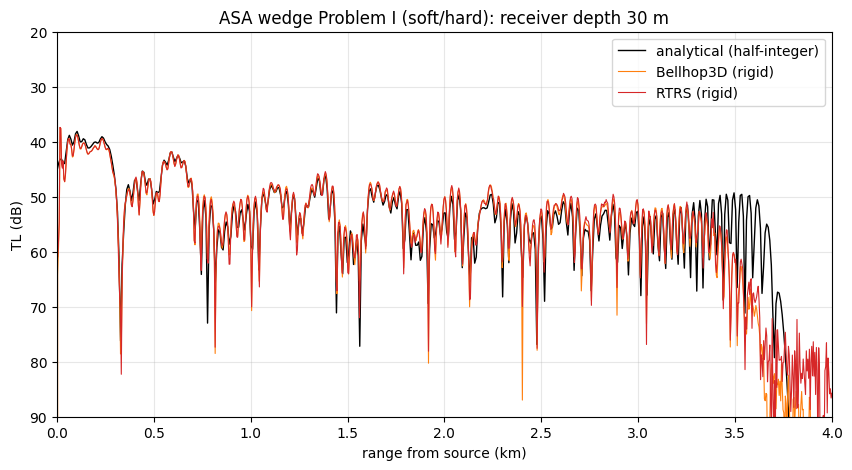

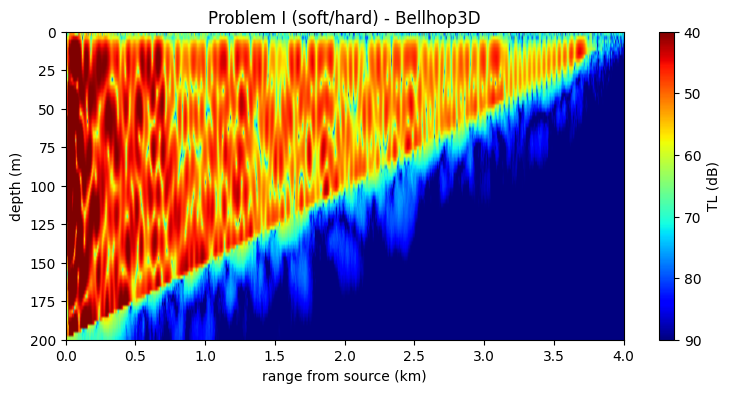

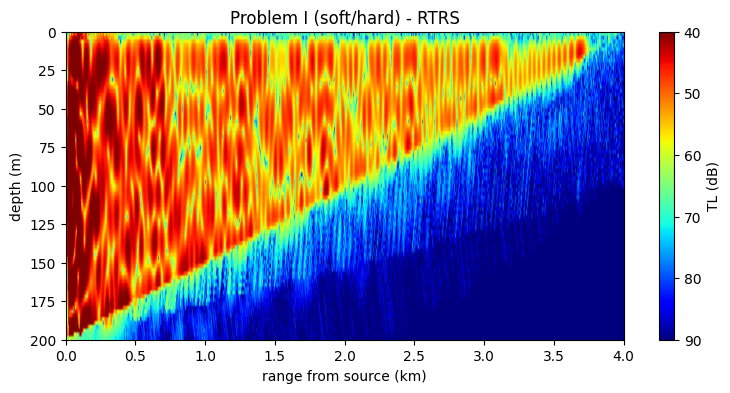

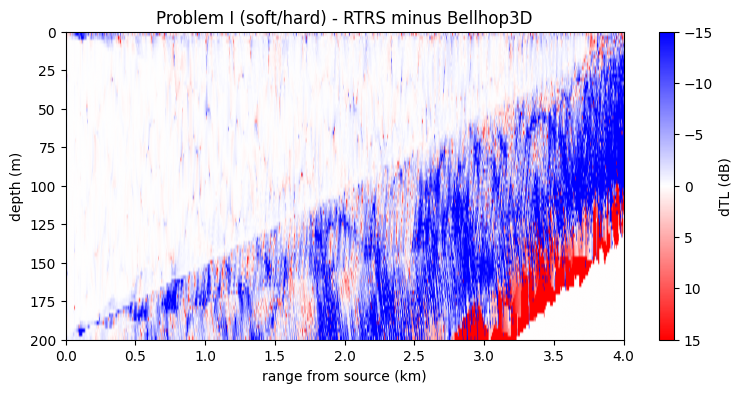

In [27]:
i30_bh = int(np.argmin(np.abs(z_bh1 - 30.0)))
i30_rt = rd_index(30.0)

plt.figure(figsize=(10, 5))
plt.plot(s_anal / 1000.0, tl_anal1, "k", lw=1.0, label="analytical (half-integer)")
plt.plot(r_bh1 / 1000.0, tl_bh1[i30_bh, :], "C1", lw=0.8, label="Bellhop3D (rigid)")
plt.plot(r_rt1 / 1000.0, tl_rt1[i30_rt, :], "C3", lw=0.8, label="RTRS (rigid)")
plt.gca().invert_yaxis()
plt.xlim(0, 4); plt.ylim(90, 20)
plt.xlabel("range from source (km)"); plt.ylabel("TL (dB)")
plt.title("ASA wedge Problem I (soft/hard): receiver depth 30 m")
plt.grid(alpha=0.3); plt.legend()

plot_wedge_fields(tl_bh1, r_bh1, tl_rt1, r_rt1, z_rt1,
                  "Problem I (soft/hard)", vmin=40, vmax=90)

# ASA wedge Problem II - penetrable lossless bottom

Pressure-release surface over a homogeneous fluid half-space bottom with sound
speed 1700 m/s, density 1.5 g/cc and no attenuation. There is no analytical
solution, so RTRS and Bellhop3D are compared to each other. Receiver depths are
30 m and 150 m.

In [28]:
bottom_props_II = [DEPTH_AT_SRC, 1700.0, 0.0, 1.5, 0.0]     # depth, cp, cs, rho, alpha
bottom_model_II = {
    "model": "acoustic",
    "compressional_speed_m_s": 1700.0,
    "density_g_cm3": 1.5,
    "compressional_attenuation_db_per_wavelength": 0.0,
}

t0 = time.time()
tl_bh2, r_bh2, z_bh2 = run_wedge_bellhop("asa_wedge_prob2", "A~", bottom_props_II)
time_bellhop_prob2 = time.time() - t0
print(f"Bellhop3D Problem II took {time_bellhop_prob2:.2f} s")

t0 = time.time()
tl_rt2, r_rt2, z_rt2 = run_wedge_rtrs(bottom_model_II)
time_rtrs_prob2 = time.time() - t0
print(f"RTRS Problem II took {time_rtrs_prob2:.2f} s")

Bellhop3D Problem II took 0.52 s
RTRS Problem II took 3.26 s


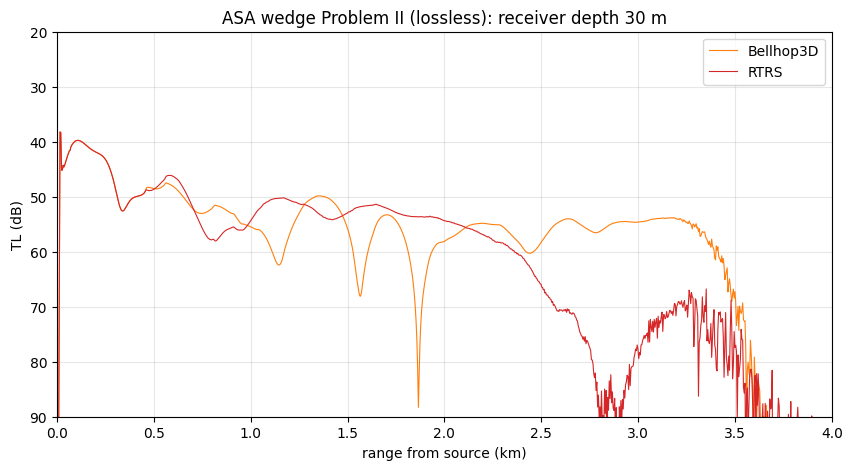

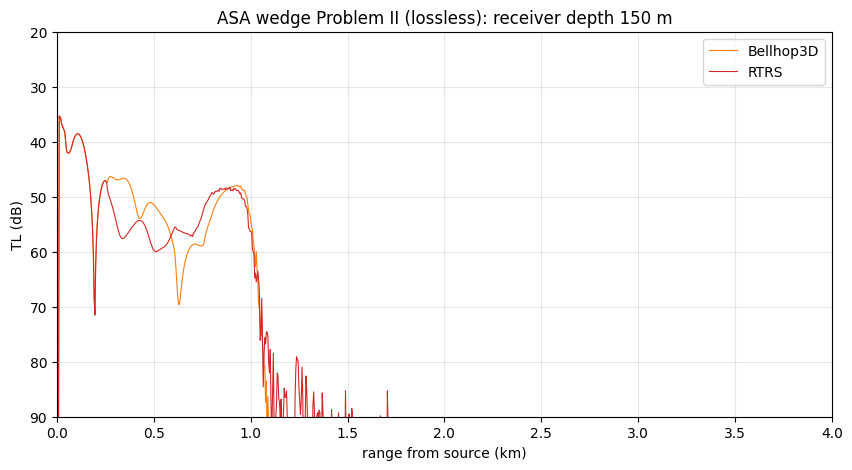

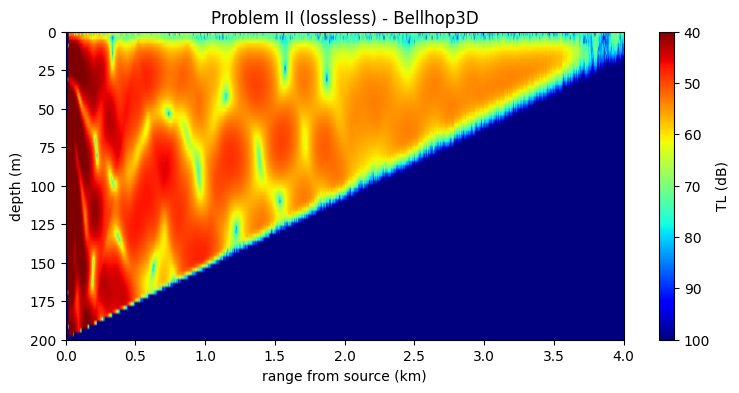

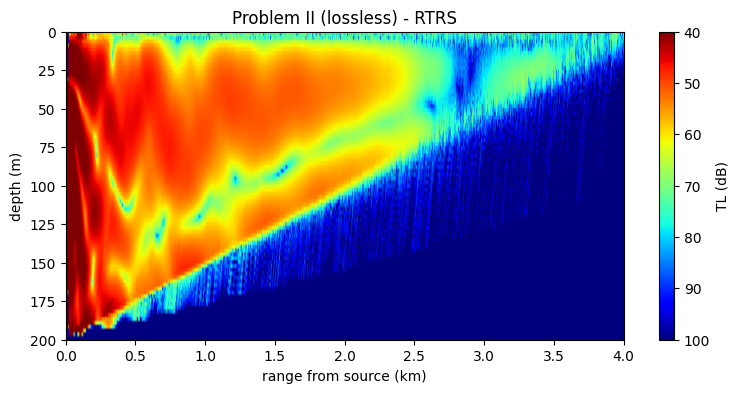

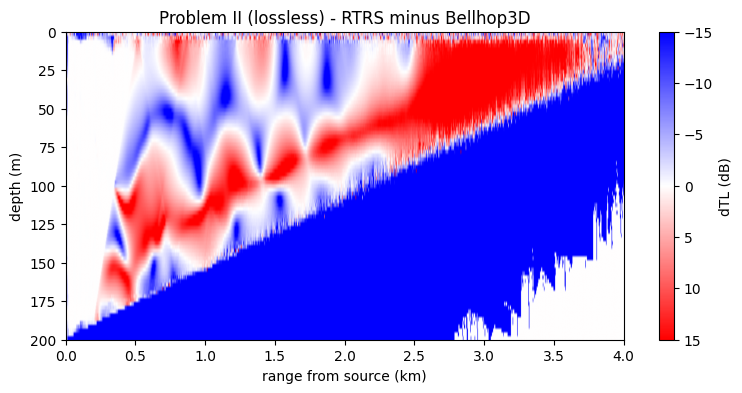

In [29]:
for rd in (30.0, 150.0):
    ib = int(np.argmin(np.abs(z_bh2 - rd)))
    ir = rd_index(rd)
    plt.figure(figsize=(10, 5))
    plt.plot(r_bh2 / 1000.0, tl_bh2[ib, :], "C1", lw=0.8, label="Bellhop3D")
    plt.plot(r_rt2 / 1000.0, tl_rt2[ir, :], "C3", lw=0.8, label="RTRS")
    plt.gca().invert_yaxis()
    plt.xlim(0, 4); plt.ylim(90, 20)
    plt.xlabel("range from source (km)"); plt.ylabel("TL (dB)")
    plt.title(f"ASA wedge Problem II (lossless): receiver depth {rd:.0f} m")
    plt.grid(alpha=0.3); plt.legend()

plot_wedge_fields(tl_bh2, r_bh2, tl_rt2, r_rt2, z_rt2,
                  "Problem II (lossless)", vmin=40, vmax=100)

# ASA wedge Problem III - penetrable lossy bottom

As Problem II but with a bottom attenuation of 0.5 dB/wavelength, the most
realistic of the three cases. No analytical solution exists, so RTRS and
Bellhop3D are compared to each other at receiver depths 30 m and 150 m.

In [30]:
bottom_props_III = [DEPTH_AT_SRC, 1700.0, 0.0, 1.5, 0.5]    # depth, cp, cs, rho, alpha
bottom_model_III = {
    "model": "acoustic",
    "compressional_speed_m_s": 1700.0,
    "density_g_cm3": 1.5,
    "compressional_attenuation_db_per_wavelength": 0.5,
}

t0 = time.time()
tl_bh3, r_bh3, z_bh3 = run_wedge_bellhop("asa_wedge_prob3", "A~", bottom_props_III)
time_bellhop_prob3 = time.time() - t0
print(f"Bellhop3D Problem III took {time_bellhop_prob3:.2f} s")

t0 = time.time()
tl_rt3, r_rt3, z_rt3 = run_wedge_rtrs(bottom_model_III)
time_rtrs_prob3 = time.time() - t0
print(f"RTRS Problem III took {time_rtrs_prob3:.2f} s")

Bellhop3D Problem III took 0.51 s
RTRS Problem III took 3.29 s


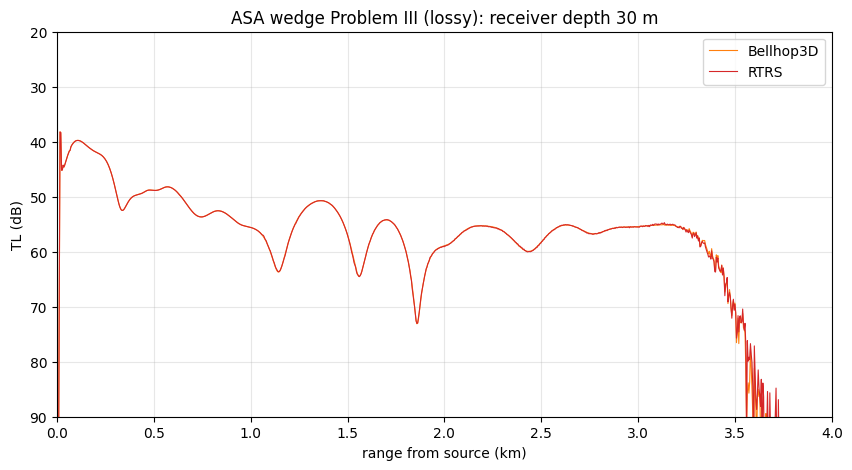

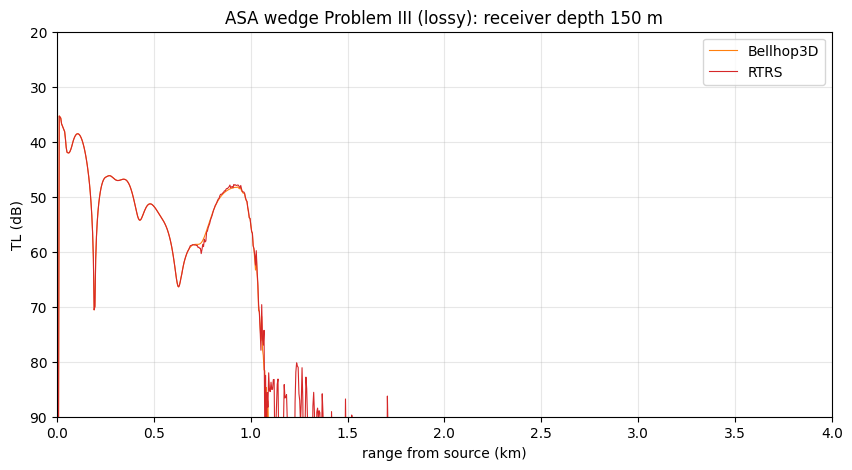

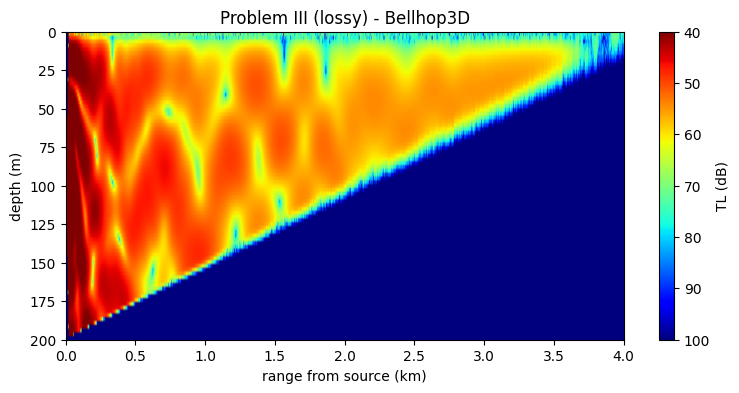

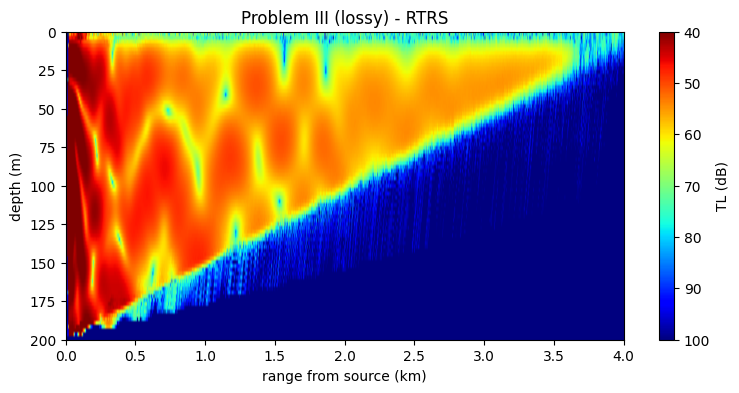

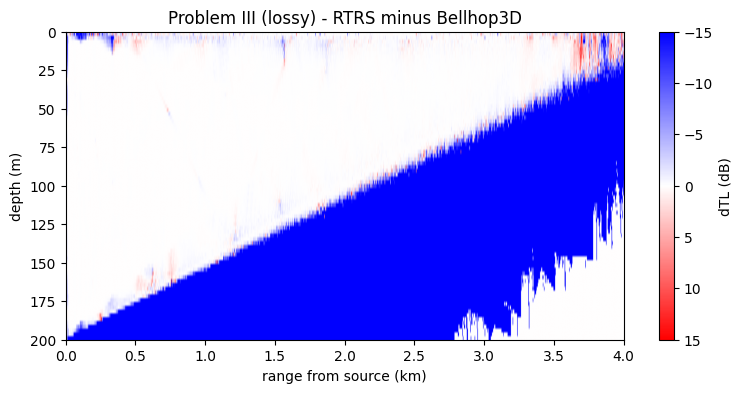

In [31]:
for rd in (30.0, 150.0):
    ib = int(np.argmin(np.abs(z_bh3 - rd)))
    ir = rd_index(rd)
    plt.figure(figsize=(10, 5))
    plt.plot(r_bh3 / 1000.0, tl_bh3[ib, :], "C1", lw=0.8, label="Bellhop3D")
    plt.plot(r_rt3 / 1000.0, tl_rt3[ir, :], "C3", lw=0.8, label="RTRS")
    plt.gca().invert_yaxis()
    plt.xlim(0, 4); plt.ylim(90, 20)
    plt.xlabel("range from source (km)"); plt.ylabel("TL (dB)")
    plt.title(f"ASA wedge Problem III (lossy): receiver depth {rd:.0f} m")
    plt.grid(alpha=0.3); plt.legend()

plot_wedge_fields(tl_bh3, r_bh3, tl_rt3, r_rt3, z_rt3,
                  "Problem III (lossy)", vmin=40, vmax=100)

In [32]:
# timing summary: Bellhop3D vs RTRS
print("timings (seconds): Bellhop3D vs RTRS")
print(f"Problem I   (soft/hard): {time_bellhop_prob1:.2f} vs {time_rtrs_prob1:.2f}")
print(f"Problem II  (lossless):  {time_bellhop_prob2:.2f} vs {time_rtrs_prob2:.2f}")
print(f"Problem III (lossy):     {time_bellhop_prob3:.2f} vs {time_rtrs_prob3:.2f}")

timings (seconds): Bellhop3D vs RTRS
Problem I   (soft/hard): 1.35 vs 3.16
Problem II  (lossless):  0.52 vs 3.26
Problem III (lossy):     0.51 vs 3.29
